# scClone2DR Tutorial

This notebook demonstrates how to use the scClone2DR package for analyzing single-cell drug response data. It covers both real data analysis and simulated data experiments.

## Prerequisites: Generate Test Data

**Important**: Before running this tutorial, you must first generate synthetic test data by running the notebook:

```
./notebooks/generate_fake_data.ipynb
```

This will create fake data that mimics the structure of the real datasets used in the paper (which are confidential and cannot be shared). The synthetic data includes:
- Single-cell RNA expression data with clone annotations
- Fast Drug response measurements
- Clone metadata

## Tutorial Contents

This notebook is divided into two main sections:

### 1. Real Data Analysis
Demonstrates the complete workflow using real-world data format:
- Loading single-cell RNA and drug response data
- Training the scClone2DR model
- Making predictions on held-out test data
- Visualizing results (fold changes, cell counts, survival probabilities)
- Analyzing clone proportions and drug effects

### 2. Simulated Data Analysis
Shows how to work with fully synthetic data where ground truth is known:
- Generating simulated training data with known parameters
- Training and evaluating model performance
- Comparing predictions against ground truth
- Comprehensive result visualization

## Quick Start

1. Run `./notebooks/generate_fake_data.ipynb` to generate simulated data
2. Execute cells sequentially in this notebook
3. Adjust parameters (train/test split, regularization, training steps) as needed

In [21]:
import sys
sys.path.append('/home/duchemin/Desktop/scClone2DR/src/')
import scclone2dr
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy

# Real Data

## Initialize Real-Data Model
Set file paths and create the scClone2DR model instance for real data.

In [16]:
path_rna = "/home/duchemin/Desktop/scClone2DR/notebooks/data/"
path_fastdrug = "/home/duchemin/Desktop/scClone2DR/notebooks/data/FD_data.csv"
datamodule = scclone2dr.data.RealData(path_fastdrug=path_fastdrug, path_rna=path_rna)

In [17]:
data_ref = datamodule.get_real_data(concentration_DMSO=5, concentration_drug=5)

Total number of samples:  100
Number of drugs 30
Number of samples:  100
<class 'numpy.float64'>


/home/duchemin/Desktop/scClone2DR/src/scclone2dr/data/realdata.py:122: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).



## Train/Test Split and Training
Split the real dataset and train the model with L1/L2 regularization.

In [18]:
idxs_train = [i for i in range(int(0.7*data_ref['N']))]
idxs_test = [i for i in range(data_ref['N']) if not(i in idxs_train)]

data_train, data_test, sample_names_train, sample_names_test = datamodule.get_real_data_split(idxs_train, idxs_test)

In [19]:
from pathlib import Path
import numpy as np
from scclone2dr.pipeline import scClone2DRPipeline
from scclone2dr.trainer import Trainer, GuideType

# 1) Build the pipeline from the already-loaded real-data module.
trainer = Trainer(guide_type=GuideType.LOWRANK_MVN, rank=10)
pipeline = scClone2DRPipeline(
    data_source=datamodule,
    trainer=trainer,
    mode_nu="noise_correction",
    mode_theta="not shared decoupled",
)

# Ensure model topology is configured from the dataset metadata.
pipeline.model.configure(datamodule)

# 2) Fit on the already prepared data_train dictionary.
params_svi = pipeline.fit(
    data=data_train,
    penalty_l1=0.1,
    penalty_l2=0.1,
    lr=0.01,
    n_steps=2000,
)

# 3) Save learned parameters.
ckpt_dir = Path("/home/duchemin/Desktop/scClone2DR/notebooks/checkpoints")
ckpt_dir.mkdir(parents=True, exist_ok=True)
ckpt_path = ckpt_dir / "real_data_pipeline_run.npz"
pipeline.save(ckpt_path)

# 4) Load trained pipeline from disk.
pipeline_loaded = scClone2DRPipeline.from_file(
    ckpt_path,
    data_source=datamodule,
)
pipeline_loaded.model.configure(datamodule)

# 5) Sample from posterior (Monte Carlo).
posterior_results = pipeline_loaded.sample_posterior(
    data=data_test,
    idxs_sample_eval=idxs_test,
    nb_ites=100,
    dir_save=None,
    sample_names=sample_names_test,
    model_name="real_data_",
)

# 6) Optional posterior predictive sample from the generative model.
posterior_predictive_data, _ = pipeline_loaded.model.sampling(data_test, params=posterior_results['params'])

print(f"Saved checkpoint: {ckpt_path}")

100%|██████████| 100/100 [00:38<00:00,  2.62it/s]

Saved checkpoint: /home/duchemin/Desktop/scClone2DR/notebooks/checkpoints/real_data_pipeline_run.npz


## Compute evaluation metrics

In [26]:
evaluations = pipeline_loaded.evaluate(data_test, posterior_results['params'])

/home/duchemin/Desktop/scClone2DR/src/scclone2dr/utils.py:102: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).



## Fold Change Scatter Plot
Compare predicted vs observed fold changes visually.

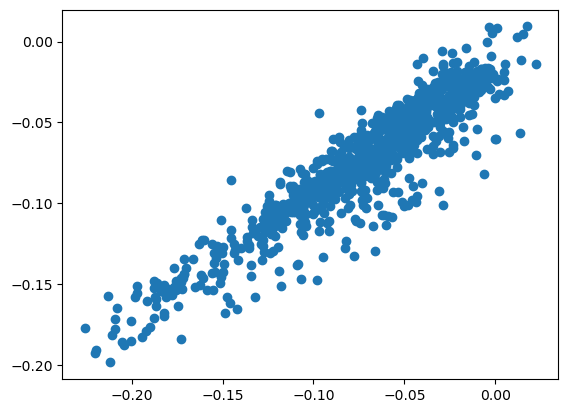

In [27]:
plt.scatter(evaluations.fold_change_data, evaluations.fold_change_pred)

## Fraction Visualization
Show tumor fractions for the validation data.

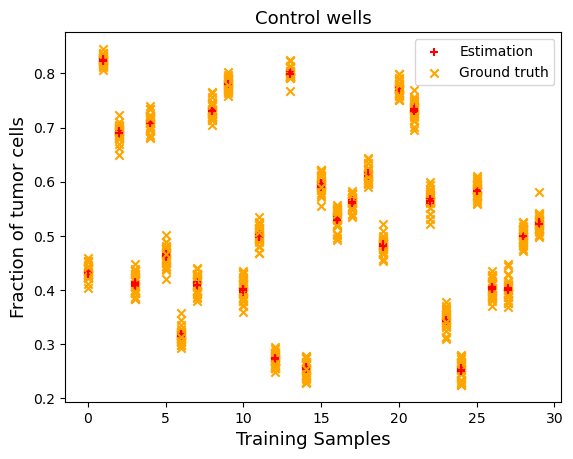

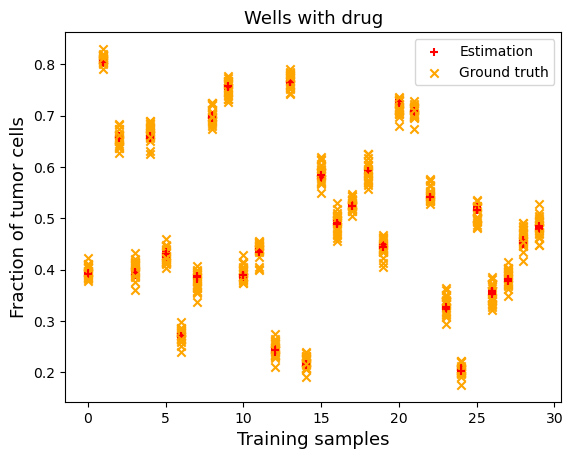

In [28]:
scclone2dr.plots.show_fractions(data_test, posterior_results['data'], idxdrug=0)

## Cell Count Visualization
Display predicted number of non-malignant cells in control wells.

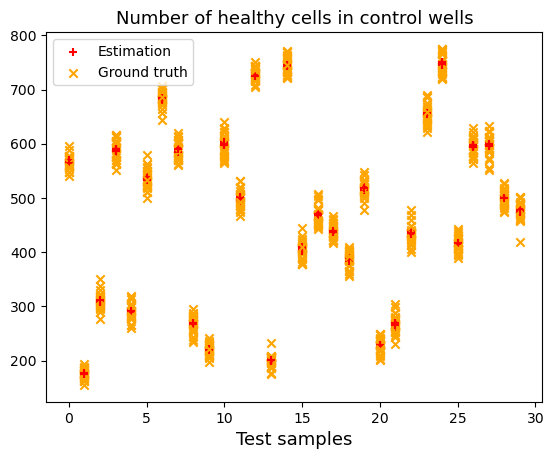

In [30]:
scclone2dr.plots.show_cells(data_test, posterior_results['data'])

## Proportion Visualization
Plot clone proportions inferred by the model.

In [31]:
scclone2dr.plots.show_proportions(data_test, posterior_results['params'])

## Beta Effects
Inspect beta parameters to interpret drug effects.

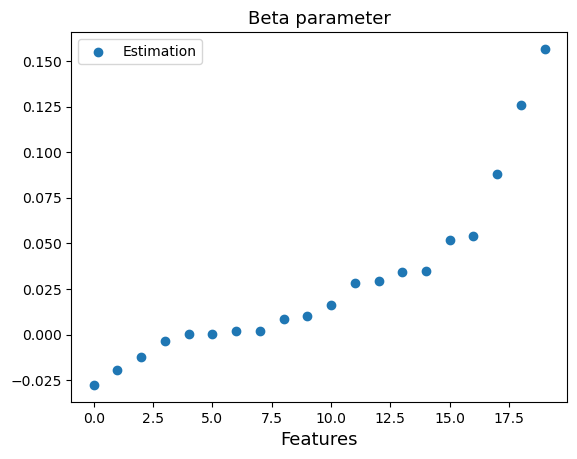

In [32]:
scclone2dr.plots.show_beta(data_test, posterior_results['params'])

## Count Scatter Plot
Visualize observed vs predicted counts.

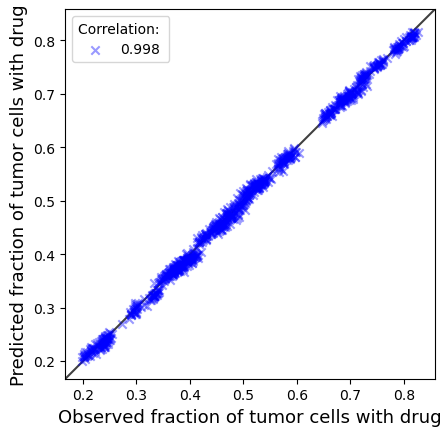

In [33]:
scclone2dr.plots.scatter_counts(data_test, posterior_results['data'])

## Survival Probabilities
Compute survival probabilities from single-cell features and plot them.

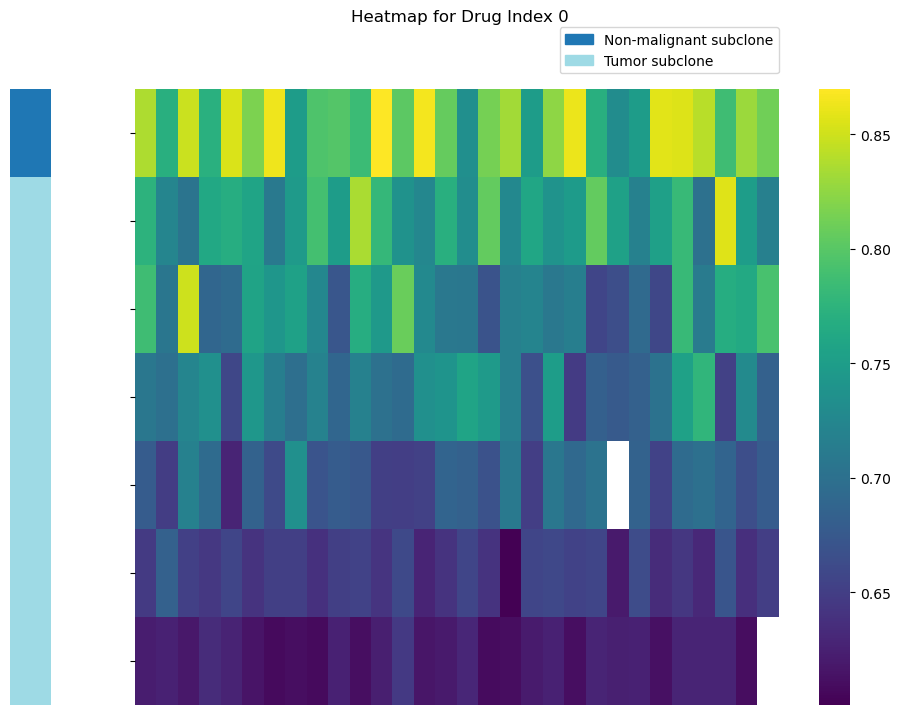

In [34]:
scclone2dr.plots.survival_probabilities(data_test, posterior_results['params']['PI'].detach().numpy(), datamodule.cluster2clonelabel, idxdrug=0)

# Simulated data

In [1]:
import sys
sys.path.append('/home/duchemin/Desktop/scClone2DR/src/')
import scclone2dr
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy

## Generate Simulated Data
Create synthetic training data with known parameters.

In [2]:
datamodule = scclone2dr.data.SimulatedData()
data_ref, gt_params = datamodule.get_simulated_training_data({'C':24,'R':5,'N':100,'Kmax':7, 'D':30, 'theta_rna':15}, neg_bin_n=100)

/home/duchemin/Desktop/scClone2DR/src/scclone2dr/utils.py:102: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['n_rna'] = torch.tensor(data_samp['n_rna'])


## Simulated Train/Test Split
Split simulated data and train the model.

In [3]:
idxs_train = [i for i in range(int(0.7*data_ref['N']))]
idxs_test = [i for i in range(data_ref['N']) if not(i in idxs_train)]

data_train, data_test = datamodule.get_data_split(data_ref, idxs_train, idxs_test)
gt_params_train, gt_params_test = datamodule.get_params_split(gt_params, idxs_train, idxs_test)

In [4]:
from pathlib import Path
import numpy as np
from scclone2dr.pipeline import scClone2DRPipeline
from scclone2dr.trainer import Trainer, GuideType

# 1) Build the pipeline from the already-loaded real-data module.
trainer = Trainer(guide_type=GuideType.NONE)
pipeline = scClone2DRPipeline(
    data_source=datamodule,
    trainer=trainer,
    mode_nu="noise_correction",
    mode_theta="not shared decoupled",
)

# Ensure model topology is configured from the dataset metadata.
pipeline.model.configure(datamodule)

# 2) Fit on the already prepared data_train dictionary.
params_svi = pipeline.fit(
    data=data_train,
    penalty_l1=0.1,
    penalty_l2=0.1,
    lr=0.01,
    n_steps=2000,
)

# 3) Save learned parameters.
ckpt_dir = Path("/home/duchemin/Desktop/scClone2DR/notebooks/checkpoints")
ckpt_dir.mkdir(parents=True, exist_ok=True)
ckpt_path = ckpt_dir / "simu_data_pipeline_run.npz"
pipeline.save(ckpt_path)

# 4) Load trained pipeline from disk.
pipeline_loaded = scClone2DRPipeline.from_file(
    ckpt_path,
    data_source=datamodule,
)

# 5) Sample from posterior (Monte Carlo).
posterior_results = pipeline_loaded.sample_posterior(
    data=data_test,
    idxs_sample_eval=idxs_test,
    nb_ites=100,
    dir_save=None,
    sample_names=idxs_test,
    model_name="simu_data_",
)

evaluations = pipeline_loaded.evaluate(data_test, posterior_results['params'], true_params=gt_params_test)

# 6) Optional posterior predictive sample from the generative model.
posterior_predictive_data, _ = pipeline_loaded.model.sampling(data_test, params=posterior_results['params'])

print(f"Saved checkpoint: {ckpt_path}")

100%|██████████| 1/1 [00:00<00:00,  3.39it/s]


Saved checkpoint: /home/duchemin/Desktop/scClone2DR/notebooks/checkpoints/simu_data_pipeline_run.npz


## True vs Predicted Plot
Scatter plot of true versus predicted fold changes.

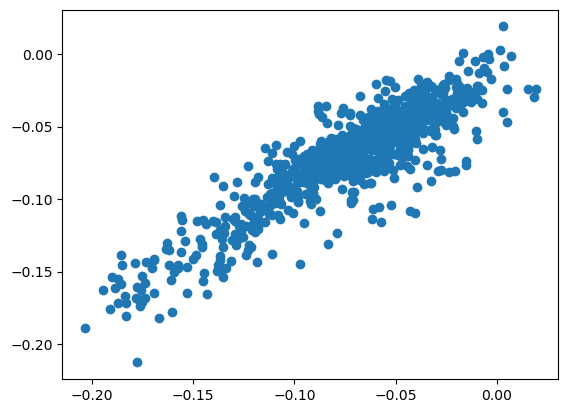

In [6]:
plt.scatter(evaluations.fold_change_true, evaluations.fold_change_pred)

## Observed vs Predicted Plot
Scatter plot of observed versus predicted fold changes.

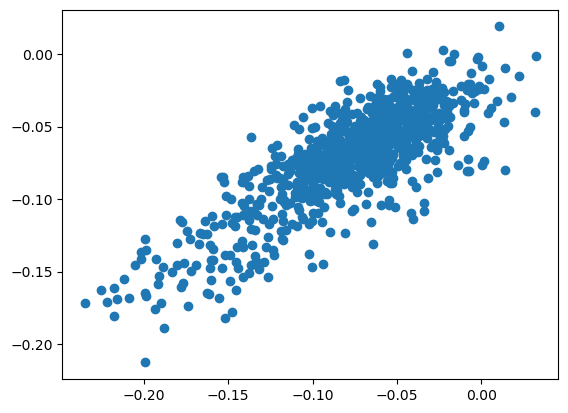

In [7]:
plt.scatter(evaluations.fold_change_data, evaluations.fold_change_pred)

## Simulated Tumour Fractions
Visualize the tumor fractions in control wells.

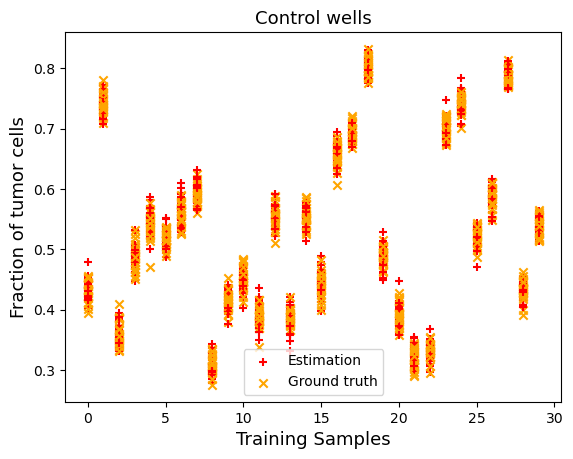

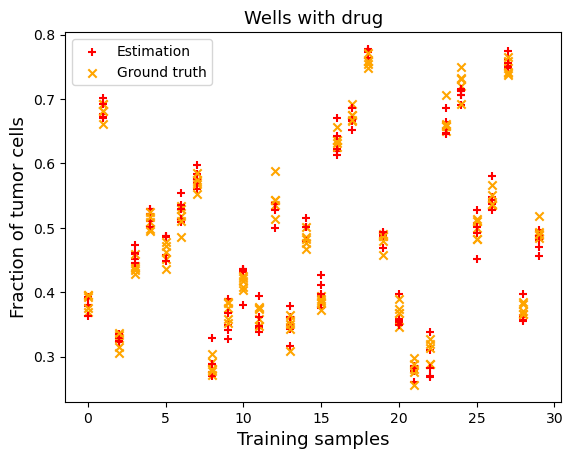

In [8]:
scclone2dr.plots.show_fractions(data_test, posterior_results['data'], idxdrug=0)

## Simulated Cell Counts
Show predicted number of non-malignant cells in control wells.

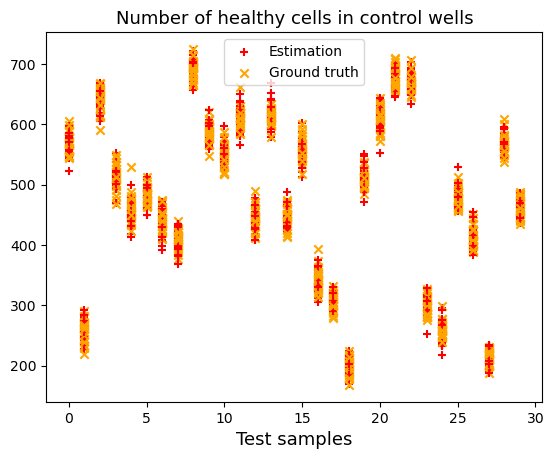

In [9]:
scclone2dr.plots.show_cells(data_test, posterior_results['data'])

## Simulated Proportions
Plot clone proportions for simulated data.

In [10]:
scclone2dr.plots.show_proportions(data_test, posterior_results['params'])

## Simulated Beta Effects
Inspect beta parameters in the simulated setting.

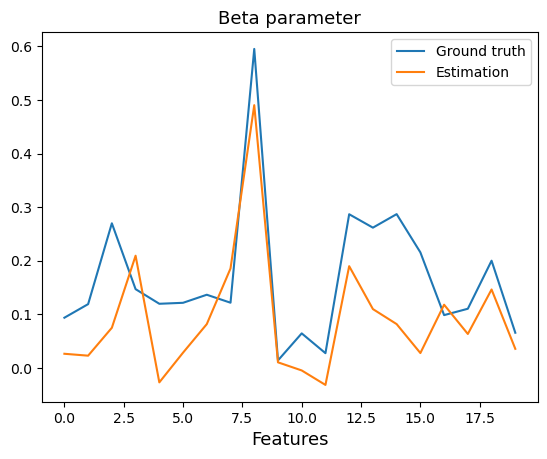

In [12]:
scclone2dr.plots.show_beta(data_test, posterior_results['params'], true_params=gt_params_test)

## Simulated Count Scatter
Visualize observed vs predicted counts for simulated data.

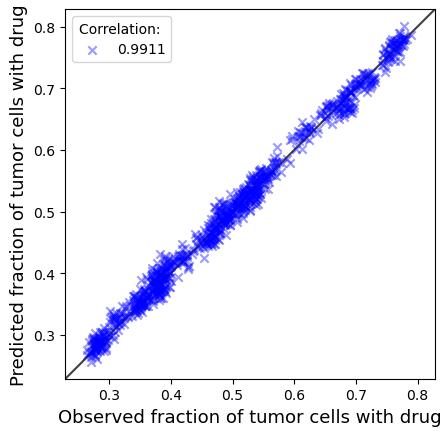

In [13]:
scclone2dr.plots.scatter_counts(data_test, posterior_results['data'])

## Subclone Survival Probabilities
Compute survival probabilities from subclone-level features.

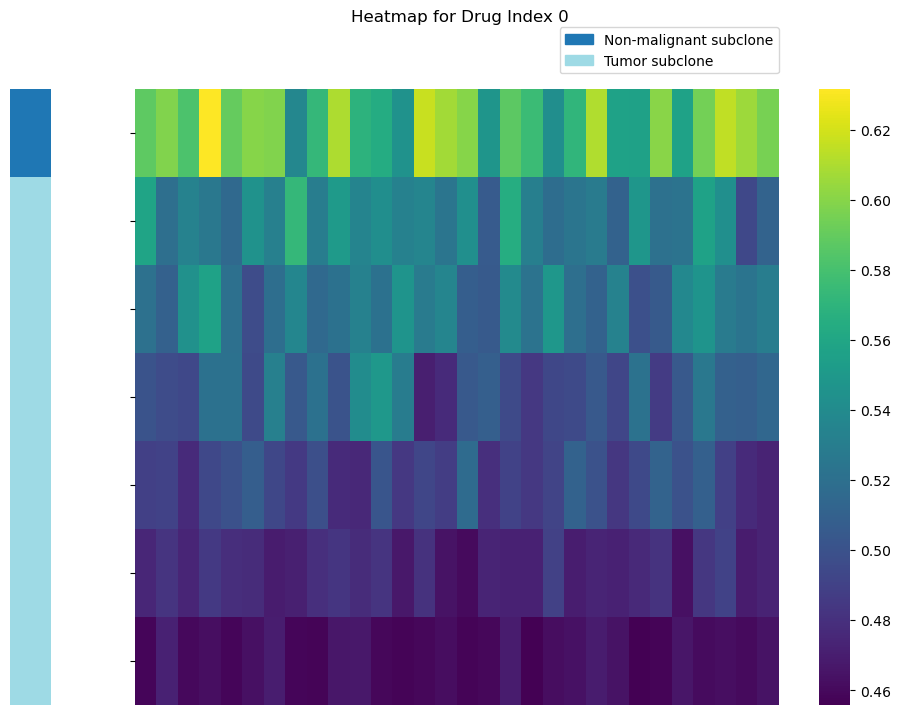

In [14]:
scclone2dr.plots.survival_probabilities(data_test, posterior_results['params']['PI'], datamodule.cluster2clonelabel, idxdrug=0)

## Compute Summary Statistics
Aggregate statistics comparing predictions to ground truth.

In [15]:
evaluations

Results(kl_proportions=0.05105512961745262, proportions=tensor([[0.4716, 0.0302, 0.1603, 0.0188, 0.0498, 0.0401, 0.2292],
        [0.1879, 0.0321, 0.0010, 0.0992, 0.1215, 0.2193, 0.3390],
        [0.5409, 0.0892, 0.0111, 0.0973, 0.0421, 0.2184, 0.0010],
        [0.4126, 0.1679, 0.2540, 0.0615, 0.0334, 0.0228, 0.0478],
        [0.3598, 0.0542, 0.3238, 0.0178, 0.0162, 0.0344, 0.1938],
        [0.3817, 0.0306, 0.0562, 0.1701, 0.1278, 0.1144, 0.1191],
        [0.3421, 0.0261, 0.0918, 0.1560, 0.2090, 0.1655, 0.0096],
        [0.3146, 0.1632, 0.0756, 0.1720, 0.0759, 0.1749, 0.0239],
        [0.5961, 0.0172, 0.0621, 0.0050, 0.2763, 0.0061, 0.0372],
        [0.4869, 0.0014, 0.0971, 0.0364, 0.1968, 0.1692, 0.0121],
        [0.4461, 0.1190, 0.0364, 0.0135, 0.0248, 0.1004, 0.2598],
        [0.5158, 0.0011, 0.1250, 0.0011, 0.1521, 0.0637, 0.1412],
        [0.3491, 0.2145, 0.0648, 0.1972, 0.0617, 0.0592, 0.0535],
        [0.5103, 0.0165, 0.3270, 0.0041, 0.0460, 0.0937, 0.0024],
        [0.3488, 0.0